In [1]:
!pip install pandas numpy matplotlib seaborn plotly kaleido openpyxl


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

print("Imports Done")

Imports Done


In [2]:
BASE = Path.cwd()

RAW = BASE / "data" / "raw"
REPORTS = BASE / "reports"
CHARTS = REPORTS / "charts"

CHARTS.mkdir(parents=True, exist_ok=True)

print(RAW)

C:\Users\chotu\Downloads\Bluestock_Mf_Capstone\data\raw


In [3]:
fund = pd.read_csv(RAW/"01_fund_master.csv")

nav = pd.read_csv(RAW/"02_nav_history.csv")

aum = pd.read_csv(RAW/"03_aum_by_fund_house.csv")

sip = pd.read_csv(RAW/"04_monthly_sip_inflows.csv")

category = pd.read_csv(RAW/"05_category_inflows.csv")

folio = pd.read_csv(RAW/"06_industry_folio_count.csv")

performance = pd.read_csv(RAW/"07_scheme_performance.csv")

transactions = pd.read_csv(RAW/"08_investor_transactions.csv")

holdings = pd.read_csv(RAW/"09_portfolio_holdings.csv")


print("Loaded Successfully")

Loaded Successfully


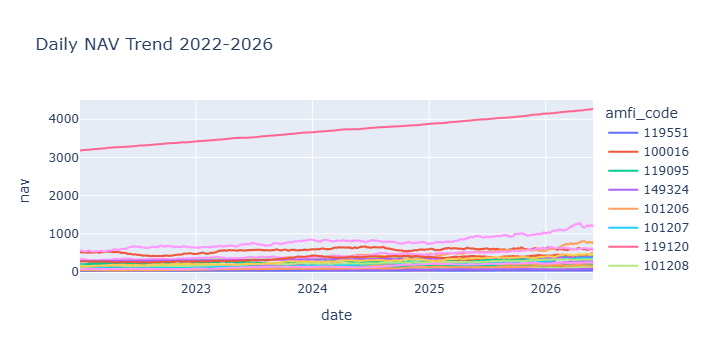

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values("date")


fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend 2022-2026"
)

fig.show()


fig.write_image(
    CHARTS/"nav_trend.png"
)

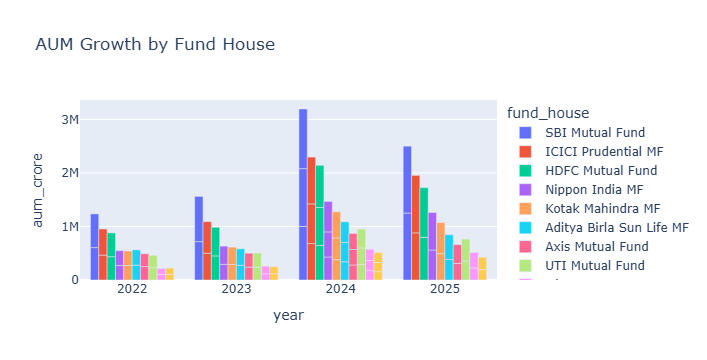

In [5]:
aum["year"] = pd.to_datetime(aum["date"]).dt.year


fig = px.bar(
    aum,
    x="year",
    y="aum_crore",
    color="fund_house",
    barmode="group",
    title="AUM Growth by Fund House"
)

fig.show()

fig.write_image(
    CHARTS/"aum_growth.png"
)

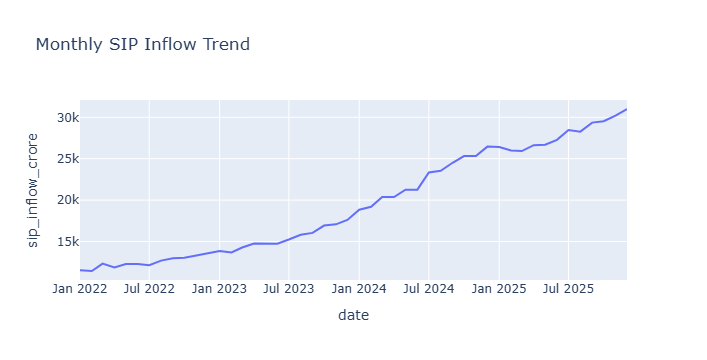

In [6]:
sip["date"] = pd.to_datetime(sip["month"])

sip = sip.sort_values("date")


fig = px.line(
    sip,
    x="date",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)


fig.show()


fig.write_image(
    CHARTS/"sip_trend.png"
)

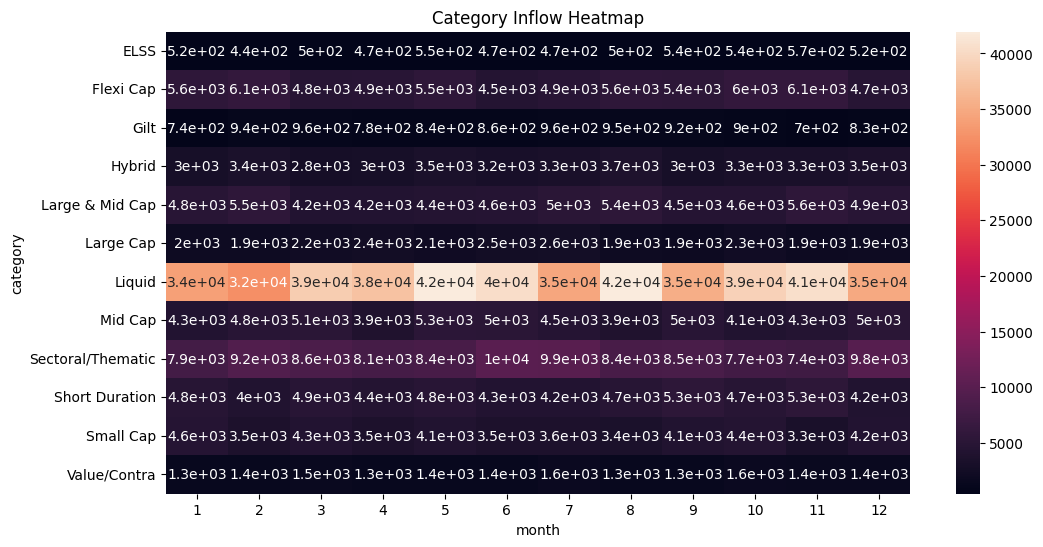

In [7]:
category["month"] = pd.to_datetime(category["month"])


pivot = category.pivot_table(
    index="category",
    columns=category["month"].dt.month,
    values="net_inflow_crore",
    aggfunc="sum"
)


plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    CHARTS/"category_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [9]:
transactions["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

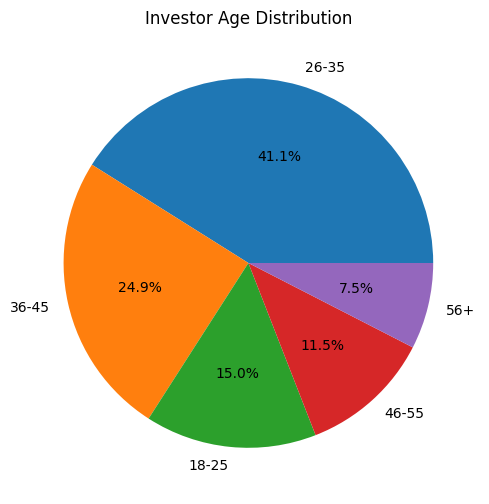

In [10]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Investor Age Distribution")

plt.savefig(
    CHARTS/"age_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [12]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

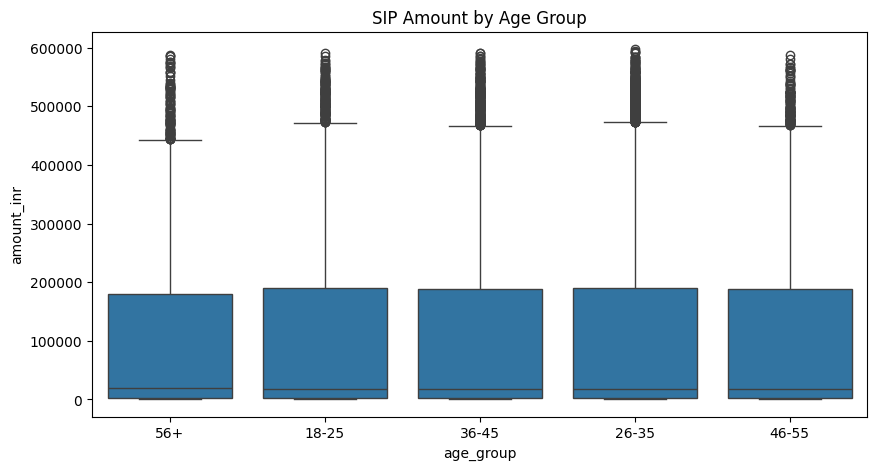

In [13]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.savefig(
    CHARTS/"sip_boxplot.png",
    bbox_inches="tight"
)

plt.show()

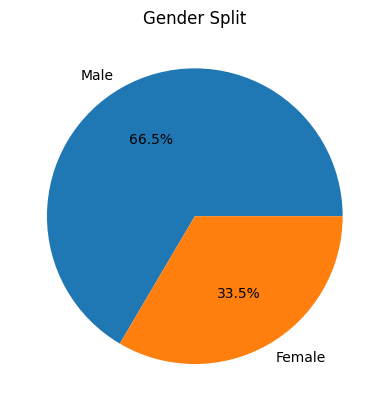

In [14]:
transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Split")

plt.savefig(
    CHARTS/"gender_split.png",
    bbox_inches="tight"
)

plt.show()

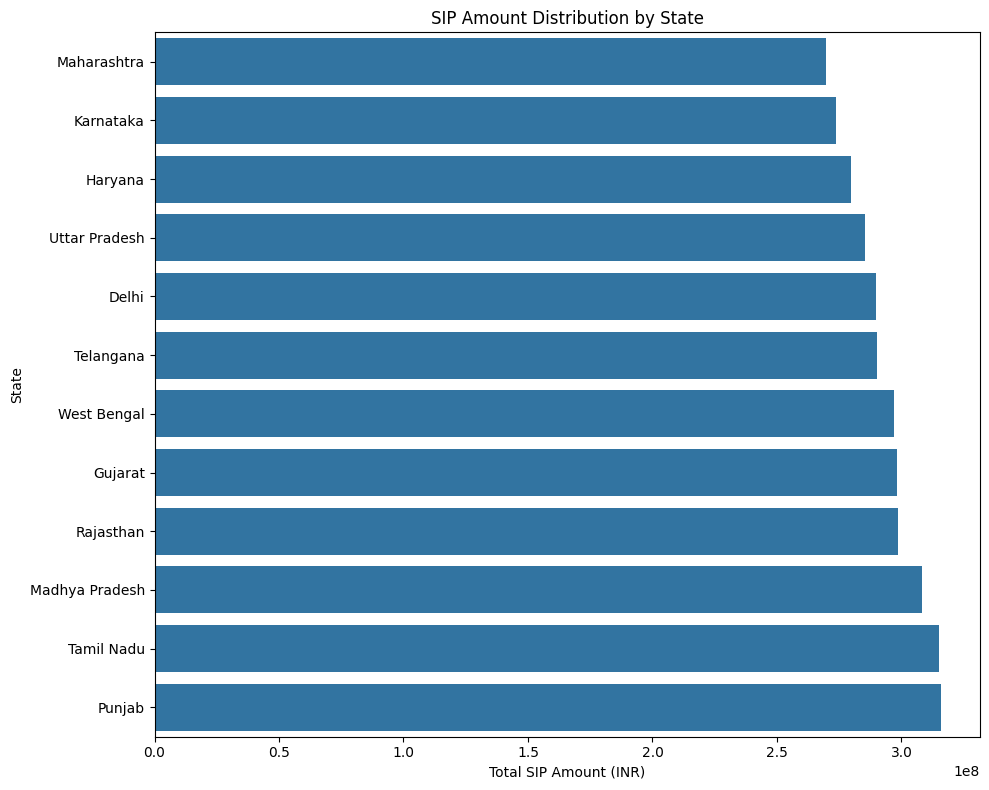

In [15]:
# Geographic distribution - SIP amount by state

state_sip = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title("SIP Amount Distribution by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    CHARTS/"state_sip_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

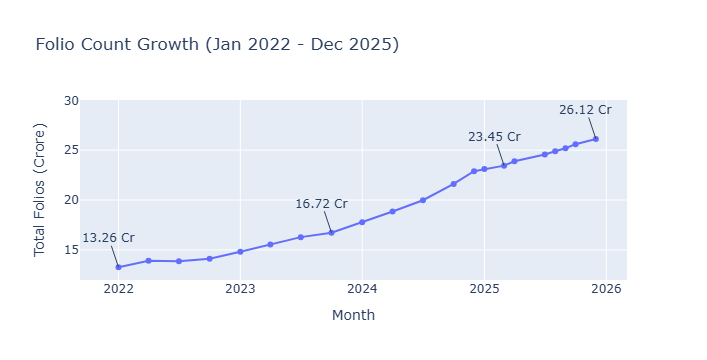

In [20]:
# Folio Count Growth Chart

folio["month"] = pd.to_datetime(folio["month"])

folio = folio.sort_values("month")


fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Folio Count Growth (Jan 2022 - Dec 2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)


# Mark milestones
milestones = folio.iloc[
    [
        0,
        len(folio)//3,
        (2*len(folio))//3,
        -1
    ]
]


for _, row in milestones.iterrows():

    fig.add_annotation(
        x=str(row["month"]),
        y=row["total_folios_crore"],
        text=f"{row['total_folios_crore']} Cr",
        showarrow=True
    )


fig.show()


# Safe export (fixes Timestamp error)
fig.write_image(
    str(CHARTS / "folio_count_growth.png")
)

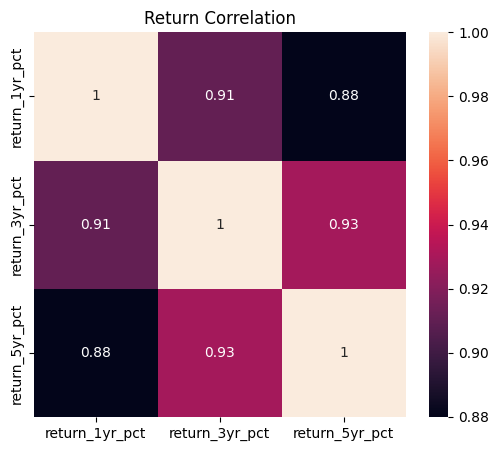

In [21]:
returns = performance[
[
"return_1yr_pct",
"return_3yr_pct",
"return_5yr_pct"
]
]


corr = returns.corr()


plt.figure(figsize=(6,5))

sns.heatmap(
corr,
annot=True
)

plt.title("Return Correlation")

plt.savefig(
CHARTS/"correlation.png",
bbox_inches="tight"
)

plt.show()

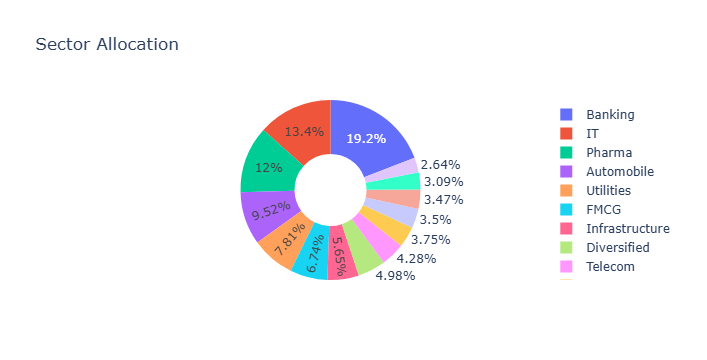

In [22]:
sector = (
holdings
.groupby("sector")["weight_pct"]
.sum()
.reset_index()
)


fig = px.pie(
sector,
names="sector",
values="weight_pct",
hole=0.4,
title="Sector Allocation"
)

fig.show()


fig.write_image(
CHARTS/"sector_donut.png"
)

In [2]:
import pandas as pd
from pathlib import Path

BASE = Path.cwd()

if BASE.name == "notebooks":
    BASE = BASE.parent

RAW = BASE / "data" / "raw"

transactions = pd.read_csv(
    RAW / "08_investor_transactions.csv"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [3]:
tier = transactions["city_tier"].value_counts()
tier

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

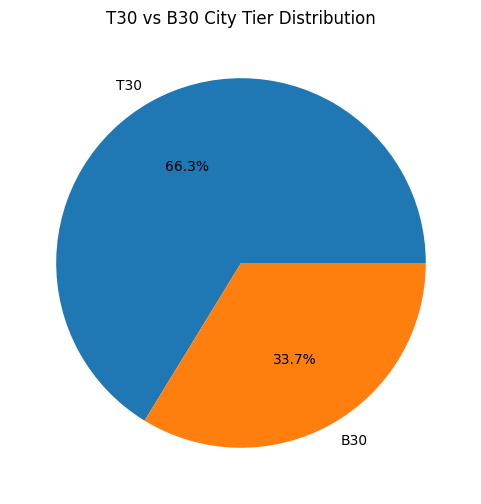

In [4]:
import matplotlib.pyplot as plt

tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

tier.plot(
    kind="pie",
    autopct="%1.1f%%",
    title="T30 vs B30 City Tier Distribution"
)

plt.ylabel("")
plt.show()

# EDA Key Findings

1. NAV showed upward movement across major schemes from 2022-2026.
   Supporting chart: NAV Trend Analysis

2. Fund houses showed different AUM growth patterns, with large AMCs dominating assets.
   Supporting chart: AUM Growth Bar Chart

3. Monthly SIP inflows increased consistently during the analysis period.
   Supporting chart: SIP Inflow Time Series

4. Category-wise mutual fund flows changed across different market conditions.
   Supporting chart: Category Inflow Heatmap

5. Investor participation was distributed across different age groups.
   Supporting chart: Investor Age Distribution

6. SIP contribution varied significantly among age groups.
   Supporting chart: SIP Amount Box Plot

7. Different states contributed differently to total SIP investments.
   Supporting chart: Geographic SIP Distribution

8. Folio count increased steadily from 2022 to 2025.
   Supporting chart: Folio Growth Trend

9. Fund return metrics showed correlation among selected schemes.
   Supporting chart: NAV Return Correlation Matrix

10. Equity portfolio allocation was diversified across multiple sectors.
    Supporting chart: Sector Allocation Donut Chart